# Optimized LIDAR Functions Test

This notebook tests the optimized/vectorized LIDAR functions from `model.py`:
- `get_intersection()` - vectorized line segment intersection
- `get_laser_ref()` - vectorized laser reflection computation
- `get_obstacles_from_map()` - uses CuPy's ndimage for connected components

Based on tests from `test_pomdp.py`


In [ ]:
import sys
import os
import time
import matplotlib.pyplot as plt

# CuPy is required - ensure CUDA_PATH is set
# This allows the notebook to work even if Jupyter wasn't started with modules loaded
if "CUDA_PATH" not in os.environ:
    print("CUDA_PATH not set, attempting to load modules...")
    import subprocess
    try:
        result = subprocess.run(
            'module load cuda/12.2 && env',
            shell=True,
            executable='/bin/bash',
            capture_output=True,
            text=True,
            timeout=10
        )
        if result.returncode == 0:
            for line in result.stdout.split('\n'):
                if '=' in line:
                    key, value = line.split('=', 1)
                    os.environ[key] = value
            print(f"✓ Modules loaded. CUDA_PATH: {os.environ.get('CUDA_PATH', 'Not set')}")
        else:
            print(f"⚠ Could not load modules. Error: {result.stderr}")
            raise RuntimeError(
                "CUDA_PATH not set and could not load modules. "
                "Please run: module load cuda/12.2 before starting Jupyter."
            )
    except Exception as e:
        print(f"✗ Could not load modules: {e}")
        raise RuntimeError(
            f"Failed to load CUDA modules: {e}\n"
            "Please ensure CUDA is loaded before starting Jupyter:\n"
            "  module load cuda/12.2"
        ) from e

# Add project root to path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

# Import - CuPy is required, will raise error if not available
from src.utils.map import load_obstacles_config
from src.classes.quantizer import SquareLatticeQuantizer
from src.classes.mapping import OCCUPIED, LidarGridMapVec
from src.classes.model import SingleIntegratorModel, LIDAR
from src.classes.pomdp import POMDP
from src.utils.array_backend import np, is_cupy

print(f"✓ All imports successful")
print(f"Using backend: {'CuPy (GPU)' if is_cupy else 'NumPy (CPU)'}")

# Test basic operations - CuPy is required
test_arr = np.array([1, 2, 3])
print(f"✓ Array creation works: {type(test_arr)}")

# Verify we're using CuPy
if not is_cupy:
    raise RuntimeError(
        "CuPy is required but not being used. "
        "Check CUDA installation and CuPy setup."
    )


✓ All imports successful
Using backend: CuPy (GPU)
✓ Array creation works: <class 'cupy.ndarray'>


## Test 1: Ray Casting Performance


In [5]:
def test_ray_casting_performance():
    """Test ray casting functionality and performance"""
    print("=== Testing Ray Casting ===")
    
    # Load obstacles and area
    all_obstacles, area = load_obstacles_config(environment='toy2')
    
    # Create motion model
    motion_model = SingleIntegratorModel(i_x=5.0, i_y=5.0, dt=0.1, max_v=5)
    
    # Create sensor
    sensor = LIDAR(fov=360, r_max=5, B=36)
    
    # Create map
    map_obj = LidarGridMapVec(
        x_min=area[0], x_max=area[1],
        y_min=area[2], y_max=area[3],
        quantization_level=3
    )
    
    # Create POMDP
    pomdp = POMDP(
        motion_model=motion_model,
        measurement_model=sensor,
        obstacles=all_obstacles,
        _map=map_obj,
        sigma_w=0.3,
        sigma_v=0.3
    )
    
    # Seed occupancy grid
    pomdp.map.seed_from_obstacles(all_obstacles)
    
    # Test single position
    X = np.array([[1.0, 2.0]])
    print(f"Testing ray casting at X={X}")
    
    start_time = time.time()
    ranges = pomdp.ray_casting(X, pomdp.map.occupancy_map.data)
    end_time = time.time()
    
    print(f"Ray casting time: {end_time - start_time:.4f}s")
    print(f"Ranges shape: {ranges.shape}")
    print(f"Number of beams: {len(ranges[0])}")
    print(f"Sample ranges: {ranges[0][:10]}")
    
    # Test multiple positions (vectorized)
    X_multiple = np.array([[1.0, 2.0], [2.0, 3.0], [3.0, 1.0]])
    print(f"\nTesting ray casting for {len(X_multiple)} positions")
    
    start_time = time.time()
    ranges_multiple = pomdp.ray_casting(X_multiple, pomdp.map.occupancy_map.data)
    end_time = time.time()
    
    print(f"Ray casting time for {len(X_multiple)} positions: {end_time - start_time:.4f}s")
    print(f"Ranges shape: {ranges_multiple.shape}")
    
    return pomdp, ranges, ranges_multiple

pomdp, ranges, ranges_multiple = test_ray_casting_performance()


=== Testing Ray Casting ===
Testing ray casting at X=[[1. 2.]]
Ray casting time: 0.0030s
Ranges shape: (1, 36)
Number of beams: 36
Sample ranges: [5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]

Testing ray casting for 3 positions
Ray casting time for 3 positions: 0.0027s
Ranges shape: (3, 36)


## Test 2: Vectorized get_laser_ref Performance


In [6]:
def test_get_laser_ref_performance(pomdp):
    """Test vectorized get_laser_ref performance"""
    print("\n=== Testing Vectorized get_laser_ref Performance ===")
    
    # Get obstacle segments
    m = pomdp.map.occupancy_map.data
    segments = pomdp.sensor.get_obstacles_from_map(m, pomdp.map)
    
    # Test single pose
    robot_pose_single = np.array([[1.0, 2.0]])
    
    start_time = time.time()
    dist_theta_single = pomdp.sensor.get_laser_ref(segments, robot_pose_single)
    end_time = time.time()
    
    print(f"Single pose time: {end_time - start_time:.4f}s")
    print(f"Distances shape: {dist_theta_single.shape}")
    print(f"Sample distances: {dist_theta_single[0][:10]}")
    
    # Test multiple poses (vectorized)
    n_poses = 10
    robot_poses_multiple = np.random.uniform(0, 5, (n_poses, 2))
    
    start_time = time.time()
    dist_theta_multiple = pomdp.sensor.get_laser_ref(segments, robot_poses_multiple)
    end_time = time.time()
    
    print(f"\n{n_poses} poses time: {end_time - start_time:.4f}s")
    print(f"Time per pose: {(end_time - start_time) / n_poses:.4f}s")
    print(f"Distances shape: {dist_theta_multiple.shape}")
    
    # Verify all distances are within valid range
    assert np.all(dist_theta_multiple >= 0), "Distances should be non-negative"
    assert np.all(dist_theta_multiple <= pomdp.sensor.r_max), "Distances should be <= r_max"
    
    print("✓ Vectorized get_laser_ref test passed")
    
    return dist_theta_single, dist_theta_multiple

dist_theta_single, dist_theta_multiple = test_get_laser_ref_performance(pomdp)



=== Testing Vectorized get_laser_ref Performance ===
Single pose time: 0.0018s
Distances shape: (1, 36)
Sample distances: [5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]

10 poses time: 0.0075s
Time per pose: 0.0007s
Distances shape: (10, 36)
✓ Vectorized get_laser_ref test passed


## Test 3: OGM to Segments Conversion


In [7]:
def test_ogm_to_segments_conversion():
    """Validate converting an occupancy grid to obstacle segments"""
    print("\n=== Testing OGM to Segments Conversion ===")
    
    # Map spanning 0..4 in both axes -> 5x5 grid
    map_vec = LidarGridMapVec(0, 4, 0, 4, quantization_level=5)
    
    motion_model = SingleIntegratorModel(i_x=0.0, i_y=0.0, dt=0.1, max_v=1.0)
    sensor = LIDAR(fov=360, r_max=10, B=36)
    
    pomdp = POMDP(
        motion_model=motion_model,
        measurement_model=sensor,
        obstacles=[],
        _map=map_vec,
        sigma_w=0.1,
        sigma_v=0.1
    )
    
    # Build occupancy grid with a 2x3 block of ones
    H, W = 5, 5
    m = np.zeros((H, W), dtype=float)
    m[1:3, 1:4] = 1.0  # component: i in {1,2}, j in {1,2,3}
    
    print(f"Occupancy grid shape: {m.shape}")
    print(f"Occupied cells: {np.sum(m)}")
    
    # Run conversion
    start_time = time.time()
    segments = pomdp.sensor.get_obstacles_from_map(m, pomdp.map)
    end_time = time.time()
    
    print(f"Conversion time: {end_time - start_time:.4f}s")
    print(f"Number of segments: {len(segments)}")
    print(f"Segments: {segments}")
    
    # Expect 4 segments (rectangle boundary)
    assert len(segments) == 4, f"Expected 4 segments, got {len(segments)}"
    
    print("✓ OGM to segments conversion test passed")
    
    return pomdp, m, segments

pomdp_ogm, m, segments = test_ogm_to_segments_conversion()



=== Testing OGM to Segments Conversion ===
Occupancy grid shape: (5, 5)
Occupied cells: 6.0
Conversion time: 0.0010s
Number of segments: 4
Segments: [(array(0.8), array(1.6), array(3.2), array(1.6)), (array(0.8), array(3.2), array(3.2), array(3.2)), (array(0.8), array(1.6), array(0.8), array(3.2)), (array(3.2), array(1.6), array(3.2), array(3.2))]
✓ OGM to segments conversion test passed


## Test 4: Observation Model


In [8]:
def test_observation_model(pomdp):
    """Test observation model Q(y | x, m)"""
    print("\n=== Testing Observation Model Q(y | x, m) ===")
    
    # Create a small set of states for testing
    X_n = SquareLatticeQuantizer(0, 3, 0, 3, n=10).get_quantized_points()
    m = pomdp.map.occupancy_map.data
    
    # Create a realistic test observation
    x_test = X_n[4]  # Use middle state
    y_test = pomdp.ray_casting(x_test[np.newaxis, :], m)[0]
    
    print(f"Testing observation model for {len(X_n)} states")
    print(f"Test observation (from state {x_test}): {y_test[:5]}... (first 5 beams)")
    
    start_time = time.time()
    Q_likelihoods = pomdp.Q(y_test, X_n, m)
    end_time = time.time()
    
    print(f"Observation model calculation time: {end_time - start_time:.4f}s")
    print(f"Likelihoods shape: {Q_likelihoods.shape}")
    print(f"Likelihoods range: [{np.min(Q_likelihoods):.6e}, {np.max(Q_likelihoods):.6e}]")
    
    # Verify properties
    assert np.all(Q_likelihoods >= 0), "Likelihoods should be non-negative"
    assert np.all(np.isfinite(Q_likelihoods)), "Likelihoods should be finite"
    assert np.any(Q_likelihoods > 0), "At least some likelihoods should be positive"
    assert np.std(Q_likelihoods) > 1e-10, "Likelihoods should vary across states"
    
    print("✓ All observation model tests passed")
    
    return Q_likelihoods

Q_likelihoods = test_observation_model(pomdp)



=== Testing Observation Model Q(y | x, m) ===
Testing observation model for 100 states
Test observation (from state [1.35 0.15]): [5. 5. 5. 5. 5.]... (first 5 beams)


Observation model calculation time: 0.4230s
Likelihoods shape: (100,)
Likelihoods range: [0.000000e+00, 2.860205e+04]
✓ All observation model tests passed


## Test 5: Performance Comparison (Single vs Vectorized)



=== Performance Comparison ===
Saved performance comparison to /global/home/hpc5656/SLAM/notebooks/outputs/lidar_visuals/performance_comparison.png


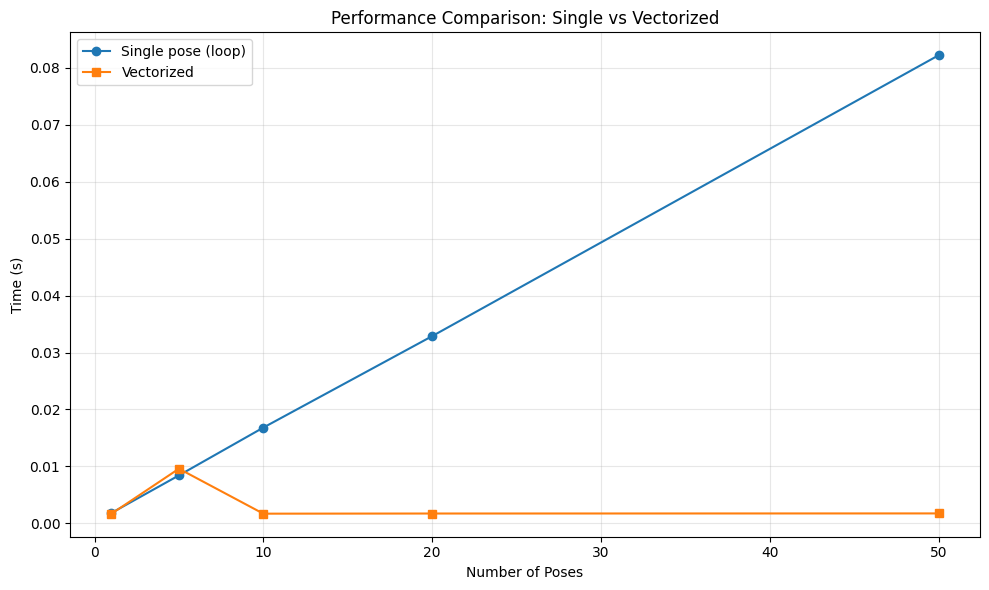

1 poses: 1.08x speedup
5 poses: 0.88x speedup
10 poses: 9.88x speedup
20 poses: 19.03x speedup
50 poses: 47.10x speedup


In [9]:
def test_performance_comparison(pomdp):
    """Compare performance of single vs vectorized processing"""
    print("\n=== Performance Comparison ===")
    
    m = pomdp.map.occupancy_map.data
    segments = pomdp.sensor.get_obstacles_from_map(m, pomdp.map)
    
    n_poses_list = [1, 5, 10, 20, 50]
    times_single = []
    times_vectorized = []
    
    for n_poses in n_poses_list:
        robot_poses = np.random.uniform(0, 5, (n_poses, 2))
        
        # Single pose processing (loop)
        start_time = time.time()
        dists_single = []
        for pose in robot_poses:
            dist = pomdp.sensor.get_laser_ref(segments, pose[np.newaxis, :])
            dists_single.append(dist[0])
        times_single.append(time.time() - start_time)
        
        # Vectorized processing
        start_time = time.time()
        dists_vectorized = pomdp.sensor.get_laser_ref(segments, robot_poses)
        times_vectorized.append(time.time() - start_time)
        
        # Verify results match
        dists_single_arr = np.array(dists_single)
        assert np.allclose(dists_single_arr, dists_vectorized, atol=1e-6), \
            f"Results don't match for {n_poses} poses"
    
    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(n_poses_list, times_single, 'o-', label='Single pose (loop)')
    plt.plot(n_poses_list, times_vectorized, 's-', label='Vectorized')
    plt.xlabel('Number of Poses')
    plt.ylabel('Time (s)')
    plt.title('Performance Comparison: Single vs Vectorized')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    output_dir = '/global/home/hpc5656/SLAM/notebooks/outputs/lidar_visuals'
    # os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, 'performance_comparison.png')
    plt.savefig(out_path, dpi=150)
    print(f"Saved performance comparison to {out_path}")
    
    plt.show()
    
    # Print speedup
    for i, n in enumerate(n_poses_list):
        speedup = times_single[i] / times_vectorized[i] if times_vectorized[i] > 0 else 0
        print(f"{n} poses: {speedup:.2f}x speedup")

test_performance_comparison(pomdp)


## Test 6: Visualization - Arena and LIDAR Hits



=== Visualizing Arena and Immediate LIDAR Hits ===
Saved arena+hits plot to: /global/home/hpc5656/SLAM/notebooks/outputs/lidar_visuals/arena_hits.png


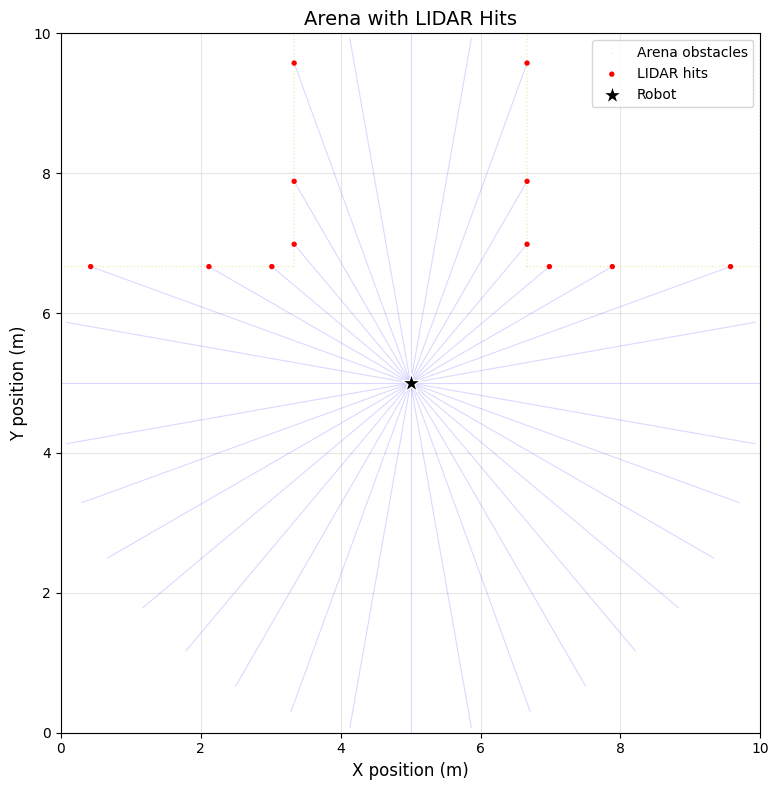

'/global/home/hpc5656/SLAM/notebooks/outputs/lidar_visuals/arena_hits.png'

In [10]:
def to_numpy(arr):
    """Convert CuPy array to NumPy array for matplotlib compatibility."""
    if hasattr(arr, 'get'):
        return arr.get()
    return arr

import numpy as np_cpu

def connect_segments(segments, resolution=0.01):
    """
    Helper function to generate dense point representation of line segments for visualization.
    Takes segments and interpolates them to create points for plotting.
    """
    for i, seg_i in enumerate(segments):
        if seg_i[1] == seg_i[3]:  # horizontal segment
            x = np_cpu.arange(min(seg_i[0], seg_i[2]), max(seg_i[0], seg_i[2]), resolution)
            y = seg_i[1] * np_cpu.ones(len(x))
        elif seg_i[0] == seg_i[2]:  # vertical segment
            y = np_cpu.arange(min(seg_i[1], seg_i[3]), max(seg_i[1], seg_i[3]), resolution)
            x = seg_i[0] * np_cpu.ones(len(y))
        else:  # gradient exists
            m = (seg_i[3] - seg_i[1]) / (seg_i[2] - seg_i[0])
            c = seg_i[1] - m * seg_i[0]
            x = np_cpu.arange(min(seg_i[0], seg_i[2]), max(seg_i[0], seg_i[2]), resolution)
            y = m * x + c
        
        obs = np_cpu.vstack((x, y)).T
        connected_segments = obs if i == 0 else np_cpu.vstack((connected_segments, obs))
    
    return connected_segments

def test_visualize_arena_and_hits(pomdp):
    """Visualize arena obstacles and overlay immediate lidar observations as red points."""
    print("\n=== Visualizing Arena and Immediate LIDAR Hits ===")
    
    # Load environment obstacles and area
    all_obstacles, area = load_obstacles_config(environment='toy2')
    
    # Build true arena segments directly from obstacle geometry (static snapshot)
    all_obstacle_segments = []
    for obs in all_obstacles:
        all_obstacle_segments += list(obs._Obstacle__get_points(obs.centroid))
    
    # Dense points for background arena visualization from segments
    # Convert to NumPy array first to ensure connect_segments works with CPU arrays
    all_obstacle_segments_np = np_cpu.array([
        tuple(to_numpy(coord) if hasattr(coord, 'get') else coord for coord in seg)
        for seg in all_obstacle_segments
    ])
    arena_points = connect_segments(all_obstacle_segments_np, resolution=0.05)
    
    # Choose a robot pose near the center
    robot_pose = pomdp.motion_model.x  # Keep as CuPy array
    
    # Lidar reflections for this pose (robot_pose is CuPy here)
    dist_theta_raw = pomdp.sensor.get_laser_ref(all_obstacle_segments, robot_pose[np.newaxis, :])[0]
    dist_theta = to_numpy(dist_theta_raw)
    angles = to_numpy(pomdp.sensor.angles)
    robot_pose_np = to_numpy(robot_pose)  # Convert for plotting
    endpoints = np_cpu.vstack([dist_theta * np_cpu.cos(angles), dist_theta * np_cpu.sin(angles)]).T + robot_pose_np
    
    # Plot
    plt.close('all')
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_title('Arena with LIDAR Hits', fontsize=14)
    
    # Arena background
    ax.scatter(arena_points[:, 0], arena_points[:, 1],
               marker='.', c='y', edgecolor='none', alpha=0.3, s=4, label='Arena obstacles')
    
    # Beams
    for i in range(len(endpoints)):
        ax.plot([robot_pose_np[0], endpoints[i, 0]], [robot_pose_np[1], endpoints[i, 1]],
                c='b', alpha=0.15, linewidth=0.8)
    
    is_hit = dist_theta < pomdp.sensor.r_max
    # Hits
    ax.scatter(endpoints[is_hit, 0], endpoints[is_hit, 1],
               marker='o', c='r', edgecolor='none', s=15, label='LIDAR hits', zorder=5)
    
    # Robot
    ax.scatter([robot_pose_np[0]], [robot_pose_np[1]], marker='*', c='k', s=200, 
               label='Robot', edgecolors='white', linewidth=1, zorder=6)
    
    ax.set_xlim([area[0], area[1]])
    ax.set_ylim([area[2], area[3]])
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('X position (m)', fontsize=12)
    ax.set_ylabel('Y position (m)', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    output_dir = '/global/home/hpc5656/SLAM/notebooks/outputs/lidar_visuals'
    # os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, 'arena_hits.png')
    plt.savefig(out_path, dpi=150)
    print(f'Saved arena+hits plot to: {out_path}')
    plt.show()
    
    return out_path
    
test_visualize_arena_and_hits(pomdp)

## Test 7: Visualization - OGM to Segments Conversion



=== Visualizing OGM to Segments Conversion ===
Grid dimensions: H=5, W=5
Occupied cells: 6.0
Number of segments recovered: 4
Saved OGM-to-segments visualization to: /global/home/hpc5656/SLAM/notebooks/outputs/lidar_visuals/ogm_segments_validation.png


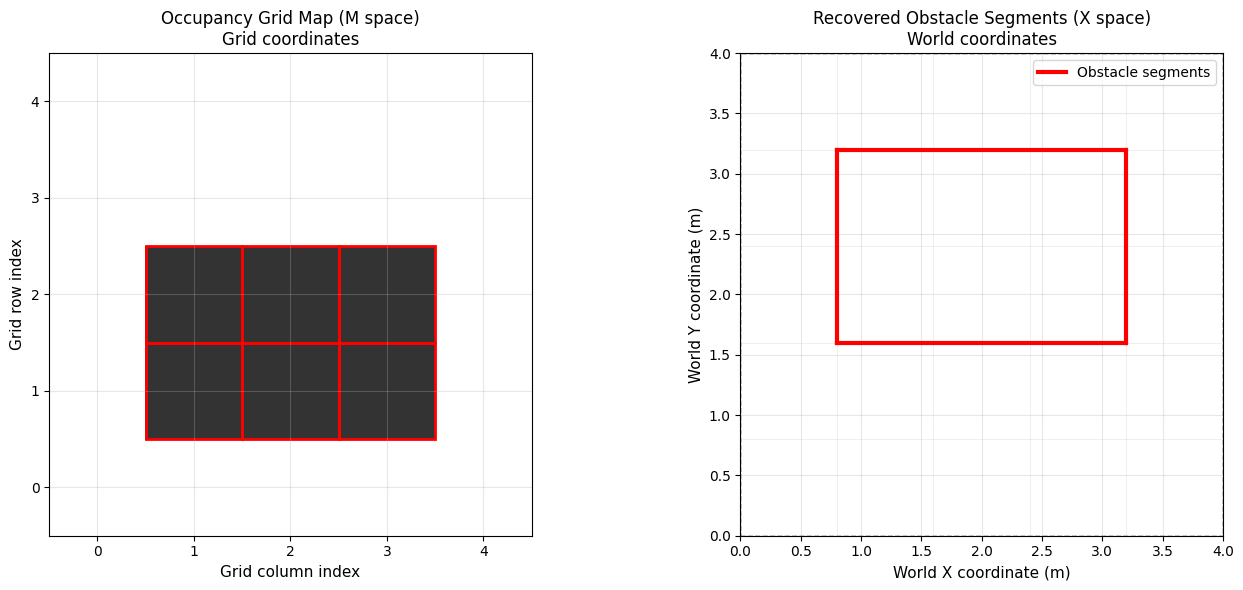

'/global/home/hpc5656/SLAM/notebooks/outputs/lidar_visuals/ogm_segments_validation.png'

In [11]:
def test_visualize_ogm_to_segments():
    """Visualize the synthetic OGM and the recovered obstacle segments in proper coordinate systems."""
    print("\n=== Visualizing OGM to Segments Conversion ===")
    
    # Recreate the same synthetic setup as in test_ogm_to_segments_conversion
    map_vec = LidarGridMapVec(0, 4, 0, 4, quantization_level=5)
    motion_model = SingleIntegratorModel(i_x=0.0, i_y=0.0, dt=0.1, max_v=1.0)
    sensor = LIDAR(fov=360, r_max=10, B=36)
    pomdp_vis = POMDP(motion_model=motion_model,
                      measurement_model=sensor,
                      obstacles=[],
                      _map=map_vec,
                      sigma_w=0.1,
                      sigma_v=0.1)
    
    H, W = map_vec.occupancy_map.height, map_vec.occupancy_map.width
    print(f"Grid dimensions: H={H}, W={W}")
    
    m = np.zeros((H, W), dtype=float)
    m[1:3, 1:4] = OCCUPIED  # 2x3 block of occupied cells
    print(f"Occupied cells: {np.sum(m)}")
    
    segments = pomdp_vis.sensor.get_obstacles_from_map(m, pomdp_vis.map)
    print(f"Number of segments recovered: {len(segments)}")
    
    # Create a proper visualization with two subplots
    plt.close('all')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Convert arrays to NumPy for matplotlib
    m_np = to_numpy(m)
    
    # Left plot: OGM in grid coordinates (M space)
    ax1.set_title('Occupancy Grid Map (M space)\nGrid coordinates', fontsize=12)
    ax1.imshow(m_np, cmap='gray_r', origin='lower', alpha=0.8)
    ax1.set_xlabel('Grid column index', fontsize=11)
    ax1.set_ylabel('Grid row index', fontsize=11)
    ax1.set_xticks(range(W))
    ax1.set_yticks(range(H))
    ax1.grid(True, alpha=0.3)
    
    # Highlight the occupied cells - use NumPy version to avoid CUDA compilation
    occupied_cells_np = np_cpu.argwhere(m_np == OCCUPIED)
    for cell in occupied_cells_np:
        ax1.add_patch(plt.Rectangle((cell[1] - 0.5, cell[0] - 0.5), 1, 1,
                                    fill=False, edgecolor='red', linewidth=2))
    
    # Right plot: Obstacle segments in world coordinates (X space)
    ax2.set_title('Recovered Obstacle Segments (X space)\nWorld coordinates', fontsize=12)
    
    # Draw the map boundaries
    map_bounds = map_vec.occupancy_map
    left_lower = to_numpy(map_bounds.left_lower)
    right_upper = to_numpy(map_bounds.right_upper)
    resolution = float(to_numpy(map_bounds.resolution)) if hasattr(map_bounds.resolution, 'get') else map_bounds.resolution
    
    ax2.add_patch(plt.Rectangle((left_lower[0], left_lower[1]),
                                right_upper[0] - left_lower[0],
                                right_upper[1] - left_lower[1],
                                fill=False, edgecolor='black', linewidth=1, linestyle='--'))
    
    # Draw grid lines to show cell boundaries
    for i in range(H + 1):
        y = left_lower[1] + i * resolution
        ax2.axhline(y=y, color='lightgray', linewidth=0.5, alpha=0.5)
    for j in range(W + 1):
        x = left_lower[0] + j * resolution
        ax2.axvline(x=x, color='lightgray', linewidth=0.5, alpha=0.5)
    
    # Draw recovered obstacle segments (red) - convert coordinates
    for seg in segments:
        x1, y1, x2, y2 = tuple(to_numpy(coord) if hasattr(coord, 'get') else coord for coord in seg)
        ax2.plot([x1, x2], [y1, y2], 'r-', linewidth=3,
                 label='Obstacle segments' if seg == segments[0] else "")
    
    ax2.set_xlim([left_lower[0], right_upper[0]])
    ax2.set_ylim([left_lower[1], right_upper[1]])
    ax2.set_xlabel('World X coordinate (m)', fontsize=11)
    ax2.set_ylabel('World Y coordinate (m)', fontsize=11)
    ax2.set_aspect('equal', adjustable='box')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    output_dir = '/global/home/hpc5656/SLAM/notebooks/outputs/lidar_visuals'
    # os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, 'ogm_segments_validation.png')
    plt.savefig(out_path, dpi=150)
    print(f'Saved OGM-to-segments visualization to: {out_path}')
    plt.show()
    
    return out_path

test_visualize_ogm_to_segments()


## Test 8: Visualization - OGM Ray Casting vs True Arena



=== Validating ray_casting: OGM + y_star vs Arena + Hits ===
Saved ray_casting validation figure to: /global/home/hpc5656/SLAM/notebooks/outputs/raycast_validation.png


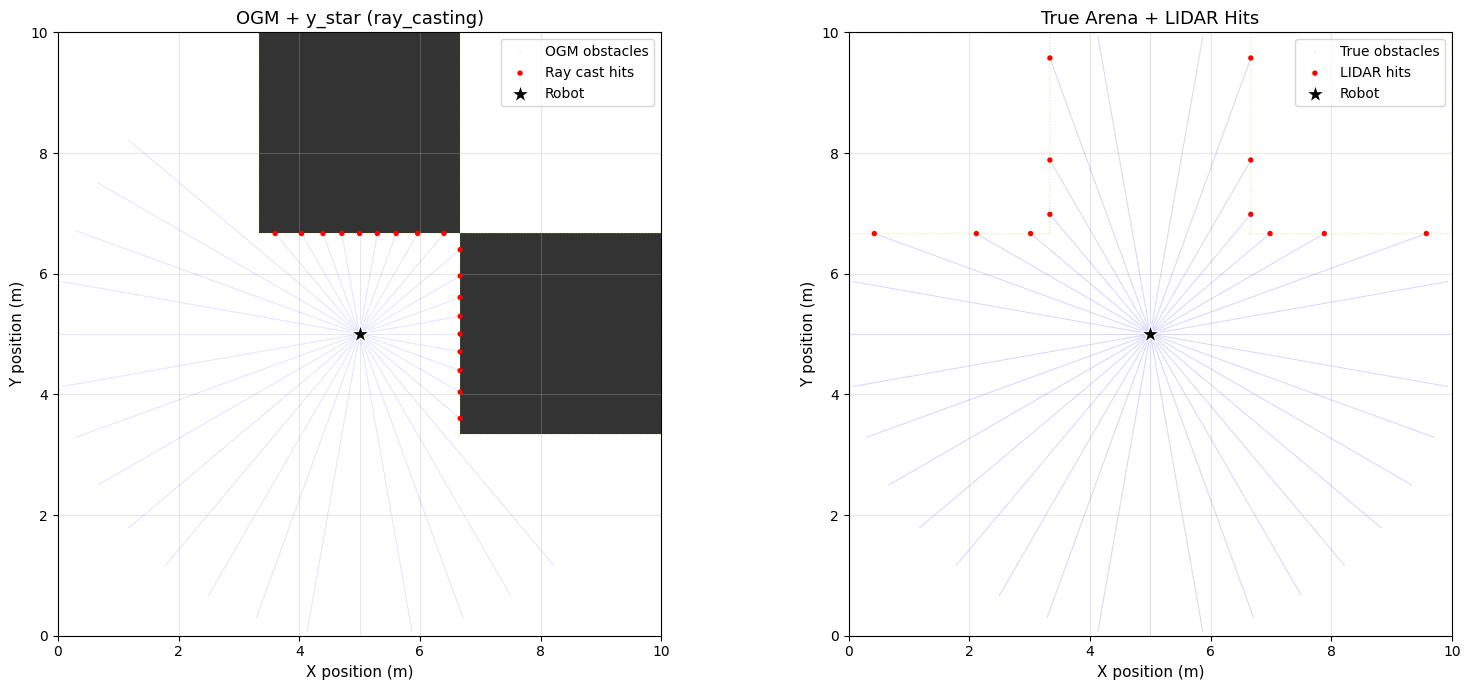

'/global/home/hpc5656/SLAM/notebooks/outputs/raycast_validation.png'

In [12]:
def test_visualize_ogm_and_raycasting_hits(pomdp):
    """Validate ray_casting by plotting OGM with y_star hits, alongside true arena + hits."""
    print("\n=== Validating ray_casting: OGM + y_star vs Arena + Hits ===")
    
    # Env and robot pose
    all_obstacles, area = load_obstacles_config(environment='toy2')
    robot_pose = pomdp.motion_model.x  # Keep as CuPy for computations
    robot_pose_np = to_numpy(robot_pose)  # Convert for plotting
    area_np = [to_numpy(a) if hasattr(a, 'get') else a for a in area]
    
    # --- Left subplot: OGM + y_star ---
    # Create a simple test OGM (3x3 grid) and modify the existing map
    # Save original map data to restore later
    original_map_data = pomdp.map.occupancy_map.data.copy()
    
    # Create desired grid pattern
    desired_grid = np_cpu.array([[0, 1, 0],
                                 [0, 0, 1],
                                 [0, 0, 0]], dtype=np_cpu.float32)
    
    # Modify the existing map data in-place (convert NumPy to CuPy)
    # Note: This modifies the map, but ray_casting will still call get_obstacles_from_map
    # which uses ndimage.label. If CUDA kernels are already compiled (from initialization),
    # this should work. Otherwise, it will fail with CUDA compilation error.
    H, W = pomdp.map.occupancy_map.data.shape
    if H == 3 and W == 3:
        # Direct assignment if shapes match - convert NumPy to CuPy
        pomdp.map.occupancy_map.data[:] = np.array(desired_grid)
        grid_data = pomdp.map.occupancy_map.data
    else:
        # If shape doesn't match, we need to create a new CuPy array
        # WARNING: This will trigger CUDA compilation in ndimage.label if not already cached
        grid_data = np.array(desired_grid)
        print(f"Warning: Map shape mismatch. Original: {H}x{W}, desired: 3x3")
        print("This may trigger CUDA compilation which could fail if headers are missing.")
    
    # y_star from ray_casting on current OGM
    y_star = pomdp.ray_casting(robot_pose[np.newaxis, :], grid_data)[0]
    angles = pomdp.sensor.angles
    y_star_np = to_numpy(y_star)
    angles_np = to_numpy(angles)
    endpoints_y = np_cpu.vstack([y_star_np * np_cpu.cos(angles_np), 
                                  y_star_np * np_cpu.sin(angles_np)]).T + robot_pose_np
    is_hit_y = to_numpy(y_star < pomdp.sensor.r_max)
    
    # --- Right subplot: True arena + hits from obstacle geometry ---
    all_obstacle_segments = []
    for obs in all_obstacles:
        all_obstacle_segments += list(obs._Obstacle__get_points(obs.centroid))
    # Convert segments to NumPy for connect_segments
    all_obstacle_segments_np = np_cpu.array([
        tuple(to_numpy(coord) if hasattr(coord, 'get') else coord for coord in seg)
        for seg in all_obstacle_segments
    ])
    arena_points = connect_segments(all_obstacle_segments_np, resolution=0.05)
    dist_theta = pomdp.sensor.get_laser_ref(all_obstacle_segments, robot_pose[np.newaxis, :])[0]
    dist_theta_np = to_numpy(dist_theta)
    endpoints_true = np_cpu.vstack([dist_theta_np * np_cpu.cos(angles_np), 
                                     dist_theta_np * np_cpu.sin(angles_np)]).T + robot_pose_np
    is_hit_true = to_numpy(dist_theta < pomdp.sensor.r_max)
    
    # Plot figure with two subplots
    plt.close('all')
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Convert grid_data to NumPy for imshow
    grid_data_np = to_numpy(grid_data)
    
    # Left: OGM + y_star + obstacles from OGM
    ax = axes[0]
    ax.set_title('OGM + y_star (ray_casting)', fontsize=13)
    # Use origin='upper' so row 0 appears at the top, matching matrix convention
    ax.imshow(grid_data_np, cmap='gray_r', origin='upper',
              extent=[area_np[0], area_np[1], area_np[2], area_np[3]], alpha=0.8)
    
    # Overlay obstacle boundaries derived from the OGM used in ray_casting
    ogm_segments = pomdp.sensor.get_obstacles_from_map(grid_data, pomdp.map)
    # Convert segments to NumPy for connect_segments
    ogm_segments_np = np_cpu.array([
        tuple(to_numpy(coord) if hasattr(coord, 'get') else coord for coord in seg)
        for seg in ogm_segments
    ])
    ogm_points = connect_segments(ogm_segments_np, resolution=0.05)
    ax.scatter(ogm_points[:, 0], ogm_points[:, 1],
               marker='.', c='y', edgecolor='none', alpha=0.35, s=4, label='OGM obstacles')
    
    # beams (faint blue)
    for i in range(len(endpoints_y)):
        ax.plot([robot_pose_np[0], endpoints_y[i, 0]], [robot_pose_np[1], endpoints_y[i, 1]],
                c='b', alpha=0.1, linewidth=0.8)
    
    # hits (red)
    ax.scatter(endpoints_y[is_hit_y, 0], endpoints_y[is_hit_y, 1], 
               c='r', s=15, edgecolor='none', label='Ray cast hits', zorder=5)
    
    # robot
    ax.scatter([robot_pose_np[0]], [robot_pose_np[1]], marker='*', c='k', s=200,
               label='Robot', edgecolors='white', linewidth=1, zorder=6)
    
    ax.set_xlim([area_np[0], area_np[1]])
    ax.set_ylim([area_np[2], area_np[3]])
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('X position (m)', fontsize=11)
    ax.set_ylabel('Y position (m)', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Right: True arena + hits
    ax = axes[1]
    ax.set_title('True Arena + LIDAR Hits', fontsize=13)
    ax.scatter(arena_points[:, 0], arena_points[:, 1],
               marker='.', c='y', edgecolor='none', alpha=0.3, s=4, label='True obstacles')
    
    for i in range(len(endpoints_true)):
        ax.plot([robot_pose_np[0], endpoints_true[i, 0]], [robot_pose_np[1], endpoints_true[i, 1]],
                c='b', alpha=0.15, linewidth=0.8)
    
    ax.scatter(endpoints_true[is_hit_true, 0], endpoints_true[is_hit_true, 1],
               marker='o', c='r', edgecolor='none', s=15, label='LIDAR hits', zorder=5)
    
    ax.scatter([robot_pose_np[0]], [robot_pose_np[1]], marker='*', c='k', s=200,
               label='Robot', edgecolors='white', linewidth=1, zorder=6)
    
    ax.set_xlim([area_np[0], area_np[1]])
    ax.set_ylim([area_np[2], area_np[3]])
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('X position (m)', fontsize=11)
    ax.set_ylabel('Y position (m)', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    output_dir = '/global/home/hpc5656/SLAM/notebooks/outputs'
    os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, 'raycast_validation.png')
    plt.savefig(out_path, dpi=150)
    print(f'Saved ray_casting validation figure to: {out_path}')
    plt.show()
    
    # Restore original map data
    pomdp.map.occupancy_map.data[:] = original_map_data
    
    return out_path

test_visualize_ogm_and_raycasting_hits(pomdp)


## Test 9: Visualization - Multiple Robot Poses
